In [24]:
# ORM + Pattern Repository 
# Este notebook demonstra:
# - Uso da biblioteca mobigreen (models + database + repositories)
# - Consultas ORM reais
# - Uso dos repositories (StationRepository, UsagerRepository)
# - Integração com pandas
# - Visualizações

from mobigreen.database import get_session
from mobigreen.models import (
    Usager, Station, Vehicule, Trajet, ZoneMetro, CapteurAir, Incident
)
from mobigreen.repositories.station_repository import StationRepository
from mobigreen.repositories.usager_repository import UsagerRepository

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [25]:
# Testar a sessão ORM

with get_session() as session:
    nb_usagers = session.query(Usager).count()
    nb_stations = session.query(Station).count()
    nb_vehicules = session.query(Vehicule).count()

    print(f"Usagers: {nb_usagers}")
    print(f"Stations: {nb_stations}")
    print(f"Véhicules: {nb_vehicules}")

Usagers: 21
Stations: 7
Véhicules: 30


In [26]:
# Listar alguns usagers e stations (ORM puro)

with get_session() as session:
    print("Exemples d'usagers:")
    for u in session.query(Usager).limit(5).all():
        print("  ", u)

with get_session() as session:
    print("Exemples de stations:")
    for s in session.query(Station).limit(5).all():
        print("  ", s)

Exemples d'usagers:
   <Usager(id=1, email='user0@example.com')>
   <Usager(id=2, email='user1@example.com')>
   <Usager(id=3, email='user2@example.com')>
   <Usager(id=4, email='user3@example.com')>
   <Usager(id=5, email='user4@example.com')>
Exemples de stations:
   <Station(id=1, nom='Victor Hugo')>
   <Station(id=2, nom='Gare SNCF')>
   <Station(id=3, nom='Caserne de Bonne')>
   <Station(id=4, nom='Hoche')>
   <Station(id=5, nom='Grand'Place')>


In [27]:
# Usando StationRepository (get_by_zone, get_disponibles)

with get_session() as session:
    station_repo = StationRepository(session)

    # Exemplo: Grenoble (code INSEE 38185)
    stations_grenoble = station_repo.get_by_zone("38185")
    print(f"Stations à Grenoble: {len(stations_grenoble)}")

    stations_dispo = station_repo.get_disponibles(nb_places_min=1)
    print(f"Stations avec places disponibles: {len(stations_dispo)}")

    for s in stations_dispo[:5]:
        taux = s.places_dispo / s.capacite * 100
        print(f"{s.nom:<25} {s.places_dispo}/{s.capacite} ({taux:.0f}%)")

Stations à Grenoble: 4
Stations avec places disponibles: 7
Victor Hugo               5/20 (25%)
Gare SNCF                 12/25 (48%)
Caserne de Bonne          7/18 (39%)
Hoche                     22/22 (100%)
Grand'Place               23/30 (77%)


In [28]:
# Usando UsagerRepository (get_by_email, get_by_abonnement, get_with_trajets)

with get_session() as session:
    usager_repo = UsagerRepository(session)

    # Exemplo: todos os usagers com abonnement "mensuel"
    mensuels = usager_repo.get_by_abonnement("mensuel")
    print(f"Usagers 'mensuel': {len(mensuels)}")

    # Carregar usagers com trajets (joinedload)
    usagers_com_trajets = usager_repo.get_with_trajets()
    print(f"Usagers avec trajets chargés: {len(usagers_com_trajets)}")

    if usagers_com_trajets:
        u = usagers_com_trajets[0]
        print(f"\nExemple: {u.prenom} {u.nom}")
        print(f"Nombre de trajets: {len(u.trajets)}")

Usagers 'mensuel': 5
Usagers avec trajets chargés: 21

Exemple: Alice Dubois
Nombre de trajets: 3


In [29]:
# Criar um novo usager via ORM + Repository

with get_session() as session:
    repo = UsagerRepository(session)

    email = "orm.test@gmail.com"
    existente = repo.get_by_email(email)

    if existente:
        print(f"Usuário com email {email} já existe (ID={existente.usr_id}).")
        nouveau = existente
    else:
        nouveau = Usager(
            nom="Test",
            prenom="ORM",
            email=email,
            type_abonnement="mensuel",
        )
        repo.create(nouveau)
        print("Usuário criado com ID:", nouveau.usr_id)

Usuário com email orm.test@gmail.com já existe (ID=21).


In [30]:
# Converter resultados ORM em DataFrame (trajets por usager)

with get_session() as session:
    usager_repo = UsagerRepository(session)
    usagers = usager_repo.get_with_trajets()

data = [
    {
        "usager": f"{u.prenom} {u.nom}",
        "nb_trajets": len(u.trajets),
    }
    for u in usagers
]

df_trajets_usager = pd.DataFrame(data)
df_trajets_usager.sort_values("nb_trajets", ascending=False, inplace=True)
df_trajets_usager.head()

,usager,nb_trajets
4,Alice Thomas,6
3,Alice Martin,5
9,Alice Bernard,4
11,Léa Richard,4
1,Léa Richard,4


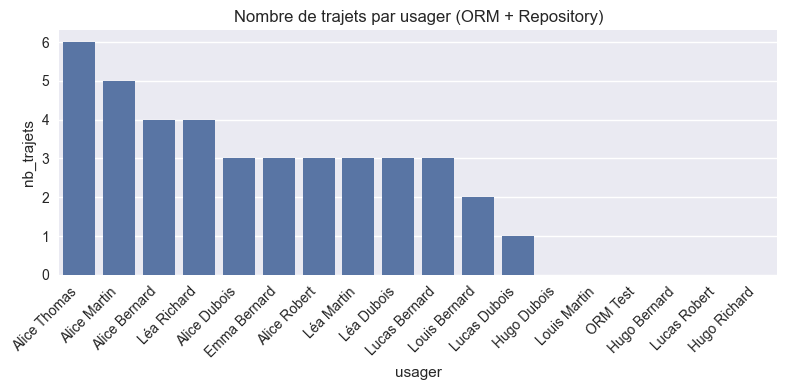

In [31]:
# Visualizar trajetos por usuários

plt.figure(figsize=(8, 4))
sns.barplot(
    data=df_trajets_usager,
    x="usager",
    y="nb_trajets",
)
plt.xticks(rotation=45, ha="right")
plt.title("Nombre de trajets par usager (ORM + Repository)")
plt.tight_layout()
plt.show()

In [32]:
# Exemplo com StationRepository — DataFrame + visualização

with get_session() as session:
    station_repo = StationRepository(session)
    stations_dispo = station_repo.get_disponibles(nb_places_min=1)

df_stations = pd.DataFrame(
    [
        {
            "station": s.nom,
            "places_dispo": s.places_dispo,
            "capacite": s.capacite,
            "taux_occupation": 100 - (s.places_dispo / s.capacite * 100),
        }
        for s in stations_dispo
    ]
)

df_stations.head()

,station,places_dispo,capacite,taux_occupation
0,Victor Hugo,5,20,75.000000
1,Gare SNCF,12,25,52.000000
2,Caserne de Bonne,7,18,61.111111
3,Hoche,22,22,0.000000
4,Grand'Place,23,30,23.333333


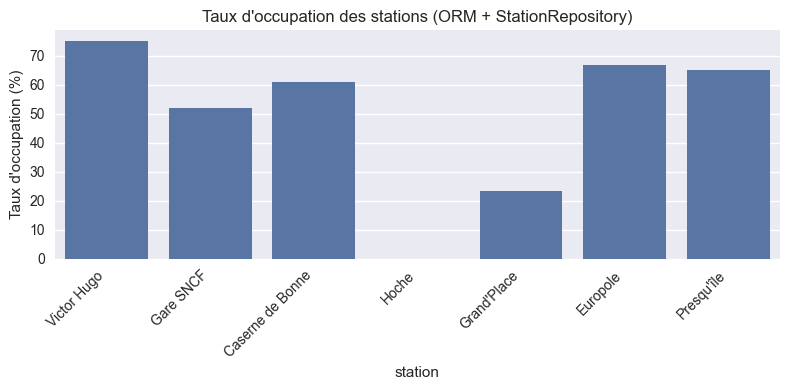

In [33]:
# Visualizar ocupação das estações

if df_stations.empty:
    print("Nenhuma estação disponível com vagas suficientes para visualização.")
else:
    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=df_stations,
        x="station",
        y="taux_occupation",
    )
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Taux d'occupation (%)")
    plt.title("Taux d'occupation des stations (ORM + StationRepository)")
    plt.tight_layout()
    plt.show()

In [34]:
# Conclusão

# - ORM + Repository funcionando perfeitamente.
# - Consultas expressivas, limpas e profissionais.
# - Integração com pandas e visualizações.